In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw1-task2.ipynb")

# Homework 1 Task 2: Simple Linear Regression 
## Do eDNA and Traditional Sampling Detect the Same Number of Fish Species?


---

### Background

Environmental DNA (eDNA) sampling detects species by collecting and sequencing genetic material shed into the water — no nets or electrofishing required. Traditional methods require direct capture or observation. This dataset, the same as used in Task 1, compiles results from **68 freshwater lake surveys** across multiple published studies, comparing species detected by each method.

Your goal is to investigate whether **eDNA-based species richness** (`dna_richness`) can predict **traditional species richness** (`trad_richness`) — the number of species found by conventional gear. This is a question for conservation monitoring: if the two methods broadly agree, eDNA could replace expensive field surveys.

You will build and evaluate a simple linear regression model from scratch using NumPy, and then verify your results with `sklearn` and `statsmodels`.

---


The dataset has the following key columns:

| Column | Description |
|---|---|
| `author` | First author of the primary study |
| `area_ha` | Lake area (hectares) |
| `dna_richness` | Number of fish species detected by eDNA |
| `trad_richness` | Number of fish species detected by conventional surveys |
| `dna_only` | Number of species found **only** by eDNA |
| `trad_only` | Number of species found **only** by conventional surveys |
| `shared` | Number of species found by **both** methods |
| `union` | Total unique species (`dna_only + trad_only + shared`) |
| `marker_cat` | Whether single or multiple genetic markers were used (single vs. multiple eDNA markers) |
| `gear_cat` | Whether single or multiple conventional survey gear types were used (single vs. multiple) |
| `total_vol_liter` | Total volume of water sampled (litres) |

### Setup: Load libraries and read in data


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv('lakes_data.csv') 
df.head()

,author,year_pub,area_ha,dna_richness,trad_richness,dna_only,trad_only,shared,union,marker_count,locus,marker_cat,gear_cat,match_effort,field_reps,rep_vol_liter,total_vol_liter
0,Civade,2016,545.0,14,18,1,5,13,19,1,12s,single,single,yes,3,45.00,135.00
1,Doble,2020,3290000.0,92,62,41,11,51,103,4,12s_16s,multiple,single,yes,21,10.00,210.00
2,Evans,2017,2.0,15,10,5,0,10,15,3,12s_16s_cytb,multiple,multiple,yes,31,0.25,7.75
3,Fujii,2019,9.0,0,7,0,7,0,7,1,12s,single,multiple,no,1,1.00,1.00
4,Fujii,2019,5.0,2,8,0,6,2,8,1,12s,single,multiple,no,1,1.00,1.00


<!-- BEGIN QUESTION -->

---
## Step 1: Visualise the Relationship

Create an exploratory data visualization exploring the relationship between `dna_richness` and `trad_richness`. 

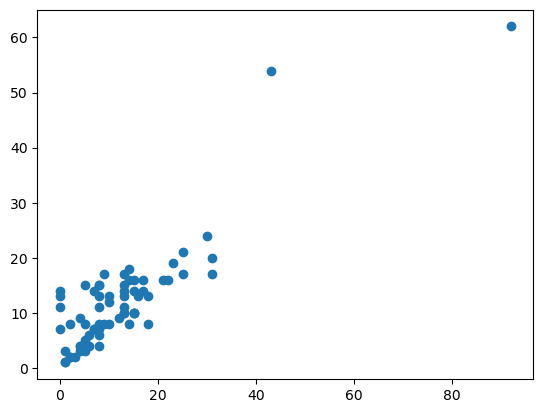

In [3]:
plt.scatter(df['dna_richness'], df['trad_richness'])



> **Q1:** Does there appear to be a relationship between the two variables? Describe the direction, form, and approximate strength.

There appears to be a strong, positive, linear relationship between the two variables.

<!-- END QUESTION -->

---
## Step 2: Fit the Regression 

Use `numpy` and the formula below to manually calculate β₁ and β₀. Store your coefficients in the `beta_1` and `beta_0` variables. Then, create a scatter plot of `trad_richness` and `dna_richness` (likely similar to the plot you created above!). Add the fitted line to the scatter plot, and the equation of the line as a legend item. 

$$\hat{\beta}_1 = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sum(x_i - \bar{x})^2} \qquad \hat{\beta}_0 = \bar{y} - \hat{\beta}_1\bar{x}$$

β₁     = 0.6519
β₀     = 4.0013


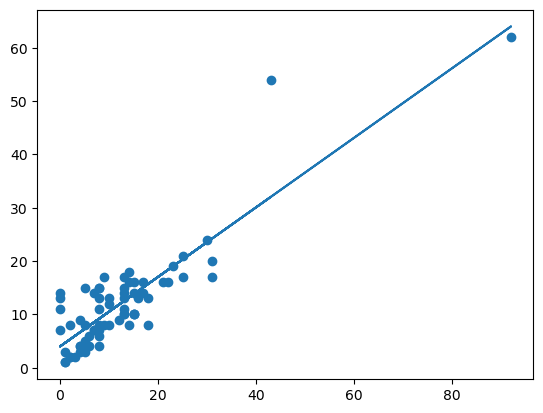

In [4]:


beta_1 = sum(np.array((df['dna_richness'] - df['dna_richness'].mean())*(df['trad_richness'] - df['trad_richness'].mean())))/sum(np.array((df['dna_richness'] - df['dna_richness'].mean())**2))
beta_0 = df['trad_richness'].mean() - beta_1*df['dna_richness'].mean()

print(f"\u03b2\u2081     = {beta_1:.4f}")
print(f"\u03b2\u2080     = {beta_0:.4f}")

plt.scatter(df['dna_richness'], df['trad_richness'])
plt.plot(df['dna_richness'], beta_0 + beta_1*df['dna_richness'])


In [5]:
grader.check("q2")

q2 results: All test cases passed!

<!-- BEGIN QUESTION -->

---
## Step 3: Interpret the Coefficients



> **Q2:** Interpret the slope in plain language. Include units.





> **Q3:** Interpret the intercept. Is it ecologically meaningful?



Q2: For every 1 species detected by eDNA, we expect 0.6519 species to be detected by traditional surveys.

Q3: When 0 species are detected by eDNA, we expect 4 species to be detected by traditional methods. This could mean that the lower bound of effectiveness of eDNA sampling is lower than the lower bound of traditional surveys. This has no bearing on the number of fish species actually present, however. 

<!-- END QUESTION -->

---
## Step 4: Compute Standard Errors

Use `numpy` and the formula below to manually calculate the standard errors. Store the RSE in a variable called `RSE`, the standard error of β₁ in a variable called `SE_beta_1`, and the standard error of β₀ in a variable called `SE_beta_0`. 

$$SS_{xx} = \sum(x_i - \bar{x})^2$$

$$RSE = \sqrt{\frac{RSS}{n-2}}$$

$$SE(\hat{\beta}_1) = \frac{RSE}{SS_{xx}}$$

$$SE(\hat{\beta}_0) = RSE \sqrt{\frac{1}{n} + \frac{\bar{x}^2}{SS_{xx}}}$$

In [6]:

yi = df['trad_richness']
y_hat = beta_0 + df['dna_richness']*beta_1
xi = df['dna_richness']
x_bar = df['dna_richness'].mean()
n = df.shape[0]

RSS =sum((yi-y_hat)**2)
SS = sum((xi-x_bar)**2)

RSE       = (RSS/(n-2))**0.5
SE_beta_1 = RSE/SS**0.5
SE_beta_0 = RSE*((1/df.shape[0])+((x_bar**2)/SS))**0.5

print(f"RSE      = {RSE:.4f}  (species)")
print(f"SE(\u03b2\u2081)   = {SE_beta_1:.4f}")
print(f"SE(\u03b2\u2080)   = {SE_beta_0:.4f}")


RSE      = 4.7441  (species)
SE(β₁)   = 0.0446
SE(β₀)   = 0.7974


In [7]:
grader.check("q4")

q4 results: All test cases passed!

---
## Step 5: Manually Calculate 95% Confidence Intervals for $\beta_0$ and $\beta_1$

Using the formula below, manually calculate an approximate 95% confidence interval for β₀ and β₁. 

$$95\% \text{ CI} \simeq \hat{\beta}_i \pm 2 \times SE(\hat{\beta})$$

In [8]:
CI_beta_1_lower = beta_1 - 2*SE_beta_1
CI_beta_1_upper = beta_1 + 2*SE_beta_1

CI_beta_0_lower = beta_0 - 2*SE_beta_0
CI_beta_0_upper = beta_0 + 2*SE_beta_0

print(f"\n95% CI for \u03b2\u2081 (slope):  ({CI_beta_1_lower:.4f},  {CI_beta_1_upper:.4f})")
print(f"95% CI for \u03b2\u2080 (intercept): ({CI_beta_0_lower:.4f},  {CI_beta_0_upper:.4f})")


95% CI for β₁ (slope):  (0.5627,  0.7411)
95% CI for β₀ (intercept): (2.4064,  5.5962)


In [9]:
grader.check("q5")

q5 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q4:** Interpret the 95% CI for the slope in plain language.

If we were to repeat this regression many times, we would expect the confidence interval of the slope to contain the true value of the slope 95% of the time. 

<!-- END QUESTION -->

---
## Step 6: Assess Model Accuracy — R²

Manually calculate the R² using the formula below. Store your answer in the `R2` variable. 

$$R^2 = 1 - \frac{RSS}{TSS} \qquad TSS = \sum_{i=1}^{n}(y_i - \bar{y})^2$$

In [10]:
y_bar = df['trad_richness'].mean()
TSS = sum((yi-y_bar)**2)

R2     = 1 - (RSS/TSS)

print(f"R\u00b2     = {R2:.4f}")

R²     = 0.7640


In [11]:
grader.check("q7")

q7 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q5:** Interpret the R² in the context of this problem.

76.4% of the variability in species recorded by traditional surveys is explained by species recoreded by eDNA. 

<!-- END QUESTION -->

---
## Step 7: Verify with `sklearn`

Let's confirm our manual OLS results using `sklearn`'s `LinearRegression`.

> **Note:** `sklearn` expects a 2D feature matrix, so we need to reshape `X` from
> shape `(n,)` to `(n, 1)` using `.reshape(-1, 1)` before fitting.

1. **Fit the model** — `LinearRegression().fit(X_2d, Y)` finds the same OLS solution as
   our manual β₁ and β₀ formulas.
2. **Extract coefficients** — `.coef_[0]` is the slope, `.intercept_` is the intercept.
3. **Compute R²** — `r2_score(Y, y_pred)` uses the $R^2 = 1 - RSS/TSS$. formula, where `y_pred = your_fitted_model.predict(X_2d)`
   
4. Create a table that compares the manually calculated and `LinearRegression()` generated slope, intercept, and R². 

If your manual calculations are correct, all three values should match `sklearn`'s output
to at least four decimal places. Any discrepancy beyond floating-point rounding
indicates a bug in your manual formulas.

In [12]:

X_2d = np.array(df['dna_richness']).reshape(-1,1)
Y = df['trad_richness']

lin_reg = LinearRegression()
lin_reg.fit(X_2d,Y)
y_pred = lin_reg.predict(X_2d)

sk_slope     = lin_reg.coef_[0]
sk_intercept = lin_reg.intercept_
sk_r2        = r2_score(Y, y_pred)

print(f"sklearn  slope     = {sk_slope:.4f},  manual slope     = {beta_1:.4f}")
print(f"sklearn  intercept = {sk_intercept:.4f},  manual intercept = {beta_0:.4f}")
print(f"sklearn  R\u00b2        = {sk_r2:.4f},  manual R\u00b2        = {R2:.4f}")

sklearn  slope     = 0.6519,  manual slope     = 0.6519
sklearn  intercept = 4.0013,  manual intercept = 4.0013
sklearn  R²        = 0.7640,  manual R²        = 0.7640


In [13]:
grader.check("q9")

q9 results: All test cases passed!

---
## Step 8: Verify with `statsmodels` 

`sklearn` is optimized for **prediction**: it fits models efficiently and scores them, but it deliberately leaves out statistical inference (standard errors, p-values, confidence intervals).

`statsmodels` is designed for **inference**: it fits the same OLS model but reports the full regression table — coefficients, standard errors, t-statistics, p-values, and confidence intervals — matching what you'd see in a statistics textbook.


1. Import `statsmodels.api as sm`.
2. Add a constant (intercept) column to `X` using `sm.add_constant()`.
3. Fit the model with `sm.OLS(Y, X_sm).fit()` and call `.summary()` to display the full regression table.
4. Extract the slope, intercept, and R² from the fitted model and compare them to your numpy and sklearn results. Store the statsmodels slope in `sm_slope`, the intercept in `sm_intercept`, and R² in `sm_r2`.

If all three methods are correct, the coefficients and R² should match to at least four decimal places.

In [14]:

import statsmodels.api as sm

X = df['dna_richness']
X_sm = sm.add_constant(X)
lin_reg_sm = sm.OLS(Y, X_sm).fit()
print(lin_reg_sm.summary())


sm_intercept = lin_reg_sm.params[0]
sm_slope     = lin_reg_sm.params[1]
sm_r2        = lin_reg_sm.rsquared


                            OLS Regression Results                            
Dep. Variable:          trad_richness   R-squared:                       0.764
Model:                            OLS   Adj. R-squared:                  0.760
Method:                 Least Squares   F-statistic:                     213.7
Date:                Thu, 09 Apr 2026   Prob (F-statistic):           2.25e-22
Time:                        12:51:08   Log-Likelihood:                -201.34
No. Observations:                  68   AIC:                             406.7
Df Residuals:                      66   BIC:                             411.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            4.0013      0.797      5.018   

C:\Users\Elijah\AppData\Local\Temp\ipykernel_18448\959170016.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sm_intercept = lin_reg_sm.params[0]
C:\Users\Elijah\AppData\Local\Temp\ipykernel_18448\959170016.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sm_slope     = lin_reg_sm.params[1]


In [15]:
grader.check("q10")

q10 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q6:** Look at the **p-values** for the slope (`dna_richness`) and intercept (`const`) in the statsmodels summary.
>
> - What does the p-value for the **slope** tell you? Is the relationship between eDNA richness and traditional richness statistically significant? How do you know?


The p-values for the slope and intercept are both very low. They are so low that they round to 0 on the display. The slope p-value tells us there is a statistically significant relationship between eDNA richness and traditional richness. This is because the probability of getting a t-statistic of this size due to random change is very low, therefore the null hypothesis of no relationship is very inlikely to be true. The p-value of the intercept tells us that the intercept is statistically significant for the same reason. 

<!-- END QUESTION -->



---

**Run the cell below to receive credit for all auto graded questions.**

In [16]:
grader.check_all()

q10 results: All test cases passed!

q2 results: All test cases passed!

q4 results: All test cases passed!

q5 results: All test cases passed!

q7 results: All test cases passed!

q9 results: All test cases passed!